## Task 3: Exploratory Data Analysis (EDA) 📊

**Goal:** Analyse the dataset to discover patterns and trends.

In [2]:
import pandas as pd
import numpy as np

# Load a sample dataset (e.g., Titanic) for demonstration
# In a real scenario, you would load your actual dataset here
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("Dataset loaded successfully. First 5 rows:")
print(df.head())

Dataset loaded successfully. First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0    

In [3]:
# ── Task 3: Exploratory Data Analysis (EDA) ──────────────────────────────────

# ── 3.1  Basic Statistics ─────────────────────────────────────────────────────
print("=" * 50)
print("DESCRIPTIVE STATISTICS (Numeric Columns)")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS (Categorical Columns)")
print("=" * 50)
print(df.describe(include=['object']))


DESCRIPTIVE STATISTICS (Numeric Columns)
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

DESCRIPTIVE STATISTICS (Categorical Col

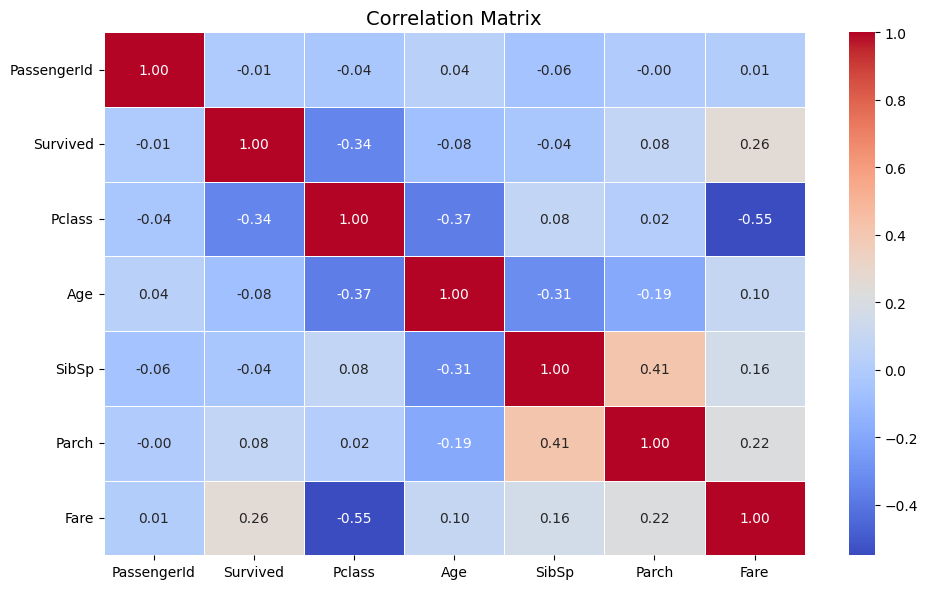

In [4]:
# ── 3.2  Correlation Matrix ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# ── 3.3  Outlier Detection (IQR Method) ──────────────────────────────────────
print("=" * 50)
print("OUTLIERS DETECTED (IQR Method)")
print("=" * 50)
for col in numeric_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"  {col}: {len(outliers)} outlier(s)")

# ── 3.4  Value Counts for Categorical Columns ─────────────────────────────────
print("\nValue Counts for Categorical Columns:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

OUTLIERS DETECTED (IQR Method)
  PassengerId: 0 outlier(s)
  Survived: 0 outlier(s)
  Pclass: 0 outlier(s)
  Age: 11 outlier(s)
  SibSp: 46 outlier(s)
  Parch: 213 outlier(s)
  Fare: 116 outlier(s)

Value Counts for Categorical Columns:

Name:
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64

Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Ticket:
Ticket
34708